In [1]:
import numpy as np 
import warnings
from scipy.optimize import root_scalar
import model_constants as const
import pandas as pd

In [2]:
####
# A Python version of the zero buoyancy plume model in Singh and O'Gorman (2013).

# >> Input parameters are:

# T_base : Base temperature of plume (K)
# qt_base: Base specific humidity of plume (kg/kg)
# p_base : Base pressure of plume (Pa)
# entrain: entrainment parameter (unitless)
#          Depends on "ent_type" (see optional arguments below)
#                 entrainment = entrain/z    [default]
#                 entrainment = entrain/1000
# RH     : environmental relative humidity (unitless, between 0 and 1)

# >> Optional arguments are:

# z_base  : Base height of plume (m) [50 m by default]
# z_top   : height to which pluem is integrated (m) [15000 m by default]
# gamma   : fraction of water that precipitates (0, 1) [1 by default]
#           0 = no fallout
#           1 = pseudo-adiabatic (all condensed water falls out immediately)
# ent_type: type of entrainment profile ['invz']
#         'invz': entrainment = entrain/z    [default]
#         'const': entrainment = entrain/1000
# deltaz  : vertical grid-spacing (m) [50 m by default]
# T_ice   : Temperature of total freezing condensate freezes 
#          gradually between 273.15 K and T_ice (K) [233.15 K by default]

# >> Outputs are:
# T_rho   : Density temperature (plume and env)   (K)
# T       : Temperature of plume                  (K)
# p       : pressure            (plume and env)   (K)
# qv      : specific humidity of plume            (kg/kg)
# qsat    : saturation specific humidity of plume (kg/kg)
# ql      : liquid water mass fraction of plume   (kg/kg)
# qi      : solid water mass fraction of plume    (kg/kg)
# z       : height                                (z)
# h       : plume moist static energy             (J/kg)
# T_env   : Temperature of environment            (K)
# q_env   : specific humidity of environment      (kg/kg)
# h_env   : environment moist static energy       (J/kg)
# ent     : entrainment rate                      (1/m)
#####

In [3]:
### function to check arguments are correct
def check_argument(var, varname, expected_type, varmin, varmax):
    """
    Check that an argument has the expected type and, if numeric,
    lies within the given bounds.

    Parameters
    ----------
    var : any
        Value to check.
    varname : str
        Name of the variable, used in error messages.
    expected_type : type or tuple[type, ...]
        Expected Python type, e.g. float, int, str, or (int, float).
    varmin : float
        Minimum allowed value for numeric inputs.
    varmax : float
        Maximum allowed value for numeric inputs.
    """
    if not isinstance(var, expected_type):
        if isinstance(expected_type, tuple):
            type_name = ", ".join(t.__name__ for t in expected_type)
        else:
            type_name = expected_type.__name__
        raise TypeError(f"Input: {varname} must be of type {type_name}")

    if isinstance(var, (int, float)):
        if var < varmin or var > varmax:
            raise ValueError(
                f"Input: {varname} outside of bounds [{varmin}, {varmax}]"
            )
    

In [4]:
def calc_fice(T, const=const):
    # Function to calculate the fraction of condensate that is ice.
    # All liquid for T > T0
    # All ice for T < T_ice
    # Linear function in between

    fliq = ( T-const.T_ice )/(const.T0-const.T_ice)
    if type(fliq)==float or type(fliq)==np.float64:
        if fliq<0:
            fliq=0
        elif fliq>1:
            fliq=1
    else:
        fliq[fliq<0] = 0
        fliq[fliq>1] = 1
    fice = 1-fliq

    return fliq, fice


def e_sat(T,const=const):
    # Function to calculate the saturation vapor pressure
    #
    # The functions are consistent with the constants given in the
    # model_constants subroutine. A faster option is available in which the
    # saturation curves are approximated as in Bolton (1980).
    #

    # Thermodynamically consistent definition of saturation curves
    # i.e. integral of Clausius-Clapeyron equation with constant heat
    # capacities. See Romps (2008).

    esl = const.e0*(T/const.T0)**((const.cpv-const.cpl)/const.Rv)* np.exp( ( const.Lv0 - const.T0*(const.cpv-const.cpl) )/const.Rv* ( 1/const.T0 - 1/T ) )

    esi = const.e0*(T/const.T0)**((const.cpv-const.cpi)/const.Rv)*np.exp( ( const.Ls0 - const.T0*(const.cpv-const.cpi) )/const.Rv* ( 1/const.T0 - 1/T ) )

    # If you want slightly faster (~10#) code, use these approximations 
    # (Bolton, 1980). Accurate to within 0.5# for T < 310 K.

    # esl = 611.2 *np. exp( 17.67      * ( T  - 273.15 ) / ( T  - 29.65 ) )
    # esi = 611.2 *np.exp( 21.8745584 * ( T  - 273.15 ) / ( T  - 7.66  ) )


    # Calculate ice fraction
    fliq,fice = calc_fice(T)

    es = fliq*esl + fice*esi

    return es, esl, esi

def qq_sat(T,p,qt=None, const=const):
    # Function to calculate the saturation specific humidity

    # Calculate saturation mixing ratio
    es, esl, esi = e_sat(T)
    rs = const.eps*es/(p-es)

    # Calculate saturation specific humidity using total water content if given
    if qt is not None:
        
        rt = qt/(1-qt)
        qs = rs/(1+np.nanmax([rt,rs]))
    else:
        qs = rs/(1+rs)
    
    return qs

def calc_saturation(p,T,q_t):
    # Function to calculate the specific humidities of vapor, liquid and solid
    # at saturation
    # calculate saturation specific humidity
    qs = qq_sat(T,p,q_t)
    q = np.minimum(q_t,qs)
    if type(q)==np.float64:
        if q<0:
            q=0
    else:
        q[q<0] = 0

    # Divide into liquid and ice
    fliq,fice = calc_fice(T)

    ql = fliq*(q_t-q)
    qi = fice*(q_t-q)

    if type(ql)==np.float64:
        if q_t-qs<0:
            ql=0
            qi=0
    else:
        ql[q_t-qs<0] = 0
        qi[q_t-qs<0] = 0


    return q,ql,qi

In [5]:
def calc_MSE(T,qt,p,z,const=const):
    # Function to calculate moist static energy

    # calculate proportions of vapor, liquid and solid
    qv,ql,qi = calc_saturation(p,T,qt)


    # calculate moist static energies of components
    hd = const.cp*(T-const.T0)  + const.g*z
    hv = const.cpv*(T-const.T0) + const.g*z + const.Lv0
    hl = const.cpl*(T-const.T0) + const.g*z
    hi = const.cpi*(T-const.T0) + const.g*z - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    h = hd*(1-qt) + qv*hv + ql*hl + qi*hi

    return h

In [6]:
def calc_Tv(T,RH,p,const=const):
    # Function to calculate virtual temperature at a given relative humidity

    # Calculate mixing ratio
    es, esl, esi  = e_sat(T)
    qv = const.eps*(RH*es/(p-RH*es*(1-const.eps)))

    # calculate virtual temperature
    Tv = T*(1+qv/const.eps-qv)

    return Tv

In [7]:
def fallout(gamma,ql,qi,dqls,T):
    # Function to calculate precipitation fallout terms

    e = np.minn([0,dqls/(1-ql-qi) ])

    fT = -gamma*e
    fliq,fice = calc_fice(T)

    fl = fT*fliq
    fs = fT*fice

    return fl, fs

In [8]:
def p_from_z(z0, z_lcl, p0, Tv_mean=298.0,const=const):
    """Approximate pressure at LCL height from hypsometric relation."""
    return p0 * np.exp(const.g * (z0-z_lcl) / (const.Rd * Tv_mean))

def q0_for_target_lcl(T0, p0, p_lcl,const=const):
    """
    Surface specific humidity required so that the parcel LCL is at p_lcl.
    """
    kappa = const.Rd / const.cp
    T_lcl = T0 * (p_lcl / p0) ** kappa
    q0 = qq_sat(T_lcl, p_lcl)
    return q0, T_lcl

def q0_for_target_lcl_height(T0, p0, z0, z_lcl, const=const):
    """
    Surface specific humidity required so that the parcel LCL is at z_lcl.
    """
    Tv_mean = T0 - 1/2 * const.g/const.cp*z_lcl
    
    p_lcl = p_from_z(z0, z_lcl, p0, Tv_mean, const)
    q0, T_lcl = q0_for_target_lcl(T0, p0, p_lcl, const)
    return q0, p_lcl, T_lcl


In [9]:
def calc_RH(T,q,p):
    es_tmp, _, _ = e_sat(T)
    e = q*p/(const.eps+(1-const.eps)*q)
    return e/es_tmp


def calc_MSE_lvl(lvl, T,qt,p,z,const=const):
    # Function to calculate moist static energy
    T_lvl = np.interp(lvl, p[::-1], T[::-1])
    qt_lvl = np.interp(lvl, p[::-1], qt[::-1])
    p_lvl = lvl 
    z_lvl = np.interp(lvl, p[::-1], z[::-1])
    # calculate proportions of vapor, liquid and solid
    qv_lvl,ql_lvl,qi_lvl = calc_saturation(p_lvl,T_lvl,qt_lvl)


    # calculate moist static energies of components
    hd_lvl = const.cp*(T_lvl-const.T0)  + const.g*z_lvl
    hv_lvl = const.cpv*(T_lvl-const.T0) + const.g*z_lvl + const.Lv0
    hl_lvl = const.cpl*(T_lvl-const.T0) + const.g*z_lvl
    hi_lvl= const.cpi*(T_lvl-const.T0) + const.g*z_lvl - (const.Ls0-const.Lv0)

    # Calculate moist static energy per unit mass of moist air
    h = hd_lvl*(1-qt_lvl) + qv_lvl*hv_lvl + ql_lvl*hl_lvl + qi_lvl*hi_lvl

    return h

In [44]:
def spectral_plume_lcl(model_type="precip",T_base = 300., qt_base = None, p_base= 100000., entrain = 0.5, RH = 0.5, 
                        z_base = 50.,z_lcl=1400., z_top = 15000., powerk = 1.0 , deltaz = 50., ent_fac  = 0.18, eta = 0.75, P=3.,
                        const=const, get_plane=True, plotting = True,save_data=True):
    if qt_base is None :
        check_argument(z_lcl     ,'z_lcl'     ,(int,float), z_base, z_top) # m
        qt_base,_,_ = q0_for_target_lcl_height(T_base,p_base,z_base,z_lcl)
       # RH = calc_RH(T_base,qt_base,p_base)
        
    ## check input argument types first
    check_argument(model_type,'model_type',(str),       0 , 0)  # 'zero-buoyancy' or 'spectral'
    check_argument(T_base     ,'T_base'     ,(int,float), 0     ,500   )  # K
    check_argument(qt_base    ,'qt_base'    ,(int,float), 0     ,1     )  # kg/kg
    check_argument(p_base     ,'p_base'     ,(int,float), 0     ,np.inf)  # Pa
    check_argument(entrain   ,'entrain'   ,(int,float), 0     ,np.inf)
    check_argument(RH        ,'RH'        ,(int,float), 0     ,1     )
    check_argument(z_base     ,'z_base'     ,(int,float), 0     ,z_top )  # m
    
    check_argument(z_top     ,'z_top'     ,(int,float), z_base, np.inf)
    check_argument(powerk    ,'powerk'    ,(int,float), 0     ,4     )
    check_argument(deltaz    ,'deltaz'    ,(int,float), 0     ,200   ) # m 
    check_argument(ent_fac   ,'ent_fac'   ,(int,float), 0.    ,1     )
    check_argument(eta       ,'eta'       ,(int,float), 0.5   ,2     )
    
    ## Set up height
    z = np.arange(z_base, z_top + deltaz, deltaz)
    if np.abs(z[-1] - z_top) > 0.1:
        z = np.append(z, z_top) # ensure last point is exactly z_top
    
    ## Entrainment profile ####################################################

    # set entrainment rate as function of z:
    # For zero-buoayncy plume model, it means the entraiment rate of the bulk
    # plume at this level z, decreasing with height as this function
    # For spectral plume model, it defines the entraiment rate of the plume
    # that detrains at this level z
    ent = 0.001*entrain*np.minimum(1.,np.maximum(0.,(z_top-z)/z_top))**powerk
    # set entrainment rate of the weakly-entrained plume
    ent_w = 0.001*entrain*np.ones_like(z)*ent_fac
    ## entrainment from precipitation
    ent_p = np.zeros_like(z)
    ent_p[z>z_lcl] = (1/z_lcl) * np.log(P/const.P0 * 0.15 * (z[z>z_lcl]-z_lcl)/z_lcl + 1)/ ((z[z>z_lcl]-z_lcl)/z_lcl)
    ent_p[z<=z_lcl] = 0
    ## Initialize arrays to hold plume properties
    p       = np.zeros_like(z)
    logp    = np.zeros_like(z)

    qv      = np.zeros_like(z)
    qsat    = np.zeros_like(z)
    
    ql      = np.zeros_like(z)
    qi      = np.zeros_like(z)
    

    T       = np.zeros_like(z)
    T_rho   = np.zeros_like(z)

    h       = np.zeros_like(z)

    T_env   = np.zeros_like(z)
    q_env   = np.zeros_like(z)
    h_env   = np.zeros_like(z)
    qsat_env = np.zeros_like(z)
    
    # undiluted plume (moist adiabat with zero entraiment), according to
    # definition of CAPE (convective available potential energy)
    T_u     = np.zeros_like(z)
    T_rho_u = np.zeros_like(z)
    qv_u    = np.zeros_like(z)
    h_u     = np.zeros_like(z)
    B_u     = np.zeros_like(z)
    CAPE_u  = 0.
    T_u[0]  = T_base
    qv_u[0] = qt_base

    # weakly-entrained plume, as a representation of the extreme convection
    T_w     = np.zeros_like(z)
    T_rho_w = np.zeros_like(z)
    qv_w    = np.zeros_like(z)
    h_w     = np.zeros_like(z)
    B_w     = np.zeros_like(z)
    CAPE_w  = 0.
    T_w[0]  = T_base
    qv_w[0] = qt_base
    
    ## Initial conditions
    p[0] = p_base
    T[0] = T_base
    qv[0] = qt_base
    
    ## Derived properties 
    logp[0] = np.log(p[0])
    h[0] = calc_MSE(T[0],qv[0],p[0],z[0])
    h_u[0]   = h[0]
    h_w[0]   = h[0]
    
    ## Flag for LCL level
    LCL = 0
    
    ## Integrate model upward
    for i in range(0,len(z)):
        # Calculate undiluted plume density temperature, buoyancy and CAPE
        T_rho[i] = T[i]*(1+qv[i]/const.eps-qv[i])
        T_rho_u[i] = T_u[i]*(1+qv_u[i]/const.eps-qv_u[i])
        B_u[i] = const.g*(T_rho_u[i]-T_rho[i])/T_rho[i]
        CAPE_u = CAPE_u+B_u[i]*deltaz
        
        # Calculate weakly-entrained plume density temperature, buoyancy and CAPE
        T_rho_w[i] = T_w[i]*(1+qv_w[i]/const.eps-qv_w[i])
        B_w[i] = const.g*(T_rho_w[i]-T_rho[i])/T_rho[i]
        CAPE_w = CAPE_w+np.maximum(B_w[i],0)*deltaz
        
        # Calculate plume saturation specific humidity
        qsat[i] = qq_sat(T[i],p[i])
        
        # Calculate environment properties
        T_env[i] = root_scalar(lambda x: calc_Tv(x, RH, p[i]) - T_rho[i],
                               x0=T[i] * (1 + 0.61 * RH * qv[i]),
                               method="newton"
                               )["root"]
        
        # Calculate environment humidity based on assumed relative humidity
        es_tmp, _, _ = e_sat(T_env[i])
        e_env = RH*es_tmp
        q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))
        
        # Calculate environment moist static energy
        h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])
        
        # Calculate environment saturation specific humidity
        qsat_env[i] = qq_sat(T_env[i],p[i])
        
        if i<len(z)-1:
            # No entrainment if unsaturated
            # Include LCL flag to prevent entrainment turning off above LCL
            if (qv[i]-qsat[i]) < 0 and LCL == 0:
                ent[i]=0
                ent_w[i] = 0
                ent_p[i] = 0
                zi_lcl = i
            else:
                LCL = 1
        
            ## Step upward - simple Euler method
            
            if LCL == 1:
                
                if model_type=='spectral':
                    if ent[i]!=0.:
                        if z[i]<z_top:
                            dent = (ent[i]-ent[i-1])/ent[i]
                        else:
                            dent = 0.
                        h[i+1] = h[i] - ent[i]*( h[i] - h_env[i] ) *( z[i+1]-z[i] ) - (h[0] - h[i])*dent/(1+eta*ent[i]*(z[i]-z[zi_lcl]))
                    else:
                        h[i+1] = h[i]

                elif model_type=='zero-buoyancy':
                    h[i+1] = h[i] - ent[i]*( h[i] - h_env[i] )*( z[i+1]-z[i] )
                    
                elif model_type=='precip':
                    # h[i+1] = h[i] - ent_p[i]*( h[i] - h_env[i] )*( z[i+1]-z[i] )
                    if ent_p[i]!=0.:
                        if z[i]<z_top:
                            dent = (ent_p[i]-ent_p[i-1])/ent_p[i]
                        else:
                            dent = 0.
                        h[i+1] = h[i] - ent_p[i]*( h[i] - h_env[i] ) *( z[i+1]-z[i] ) - (h[0] - h[i])*dent/(1+eta*ent_p[i]*(z[i]-z_lcl))
                    else:
                        h[i+1] = h[i]
                else:
                    raise ValueError("Invalid model_type. Must be 'spectral' or 'zero-buoyancy'.")
            else:
                h[i+1] = h[i] 
                
            h_u[i+1] = h_u[i]
            
            h_w[i+1] = h_w[i] - ent_w[i]*( h_w[i] - h_env[i] ) *( z[i+1]-z[i] )
            
            logp[i+1] = logp[i] - const.g/(const.Rd*T_rho[i])*( z[i+1]-z[i] )
            
            ## Calculate pressure
            p[i+1]  = np.exp(logp[i+1])

            # Calculate Temperature via root finding algorithm
            T[i+1] = root_scalar(lambda x: calc_MSE(x, qv[i], p[i+1], z[i+1]) - h[i+1],
                                x0=T[i], method="newton"
                            )["root"]

    
            # Calculate Undiluted Temperature via root finding algorithm
            T_u[i+1] = root_scalar(lambda x: calc_MSE(x, qv_u[i], p[i+1], z[i+1]) - h_u[i+1],
                                x0=T_u[i], method="newton"
                            )["root"]
            
            # Calculate Weakly Diluted Temperature via root finding algorithm
            T_w[i+1] = root_scalar(lambda x: calc_MSE(x, qv_w[i], p[i+1], z[i+1]) - h_w[i+1],
                                x0=T_w[i], method="newton"
                            )["root"]

            # Calculate specific humidity
            qv[i+1] = np.minimum(qq_sat(T[i+1],p[i+1]),qv[i])
            
            # Calculate undilated specific humidity
            qv_u[i+1] = np.minimum(qq_sat(T_u[i+1],p[i+1]),qv_u[i])
            
            # Calculate undilated specific humidity
            qv_w[i+1] = np.minimum(qq_sat(T_w[i+1],p[i+1]),qv_w[i])
    
    #### end of for loop
    h_w = np.maximum(h_w,h)
    T_w = np.maximum(T_w,T_env)
    T_rho_w = np.maximum(T_rho_w,T_rho)
    qv_w = np.maximum(qv_w,qv)

    rhs = qt_base/qq_sat(T_base,p_base)
    
    ### CoPilot helped me explaine the for loop below
    # Adjust environment temperature and humidity below LCL to be 
    # consistent with the assumed relative humidity,
    # which is not guaranteed by the model integration above
    for i in range(0,len(z)):
        if i<=zi_lcl:
            rh = RH+(rhs-RH)*(z[zi_lcl]+z_base-z[i])/z[zi_lcl]
            # Use root finding algorithm with initial guess
            T_env[i] = root_scalar(lambda x: calc_Tv(x, RH, p[i]) - T_rho[i],
                               x0=T[i] * (1 + 0.61 * RH * qv[i]),
                               method="newton"
                               )["root"]
            
            # Calculate environment humidity based on assumed relative humidity
            es_tmp, _, _ = e_sat(T_env[i])
            e_env = rh*es_tmp
            q_env[i] = const.eps*(e_env/(p[i]-e_env*(1-const.eps)))

            # Calculate environment moist static energy
            h_env[i] = calc_MSE(T_env[i],q_env[i],p[i],z[i])

    h[z>z_top]=np.nan
    T[z>z_top]=np.nan
    T_rho[z>z_top]=np.nan
    ## calcualte MSE difference between 850 hPa and 500 hPa
    h850 = calc_MSE_lvl(85000,T,qv,p,z,const)
    h500 = calc_MSE_lvl(50000,T,qv,p,z,const)
    dh = h500-h850
    
    ## Saturation deficit
    mask = (p <= 85000) & (p >= 50000)
    z_layer = z[mask]
    dz = z_layer[-1] - z_layer[0]
    sat_def = qsat_env[mask] - q_env[mask]
    deficit_mid = 0.5* (sat_def[:-1]+sat_def[1:])
    # Height-weighted mean deficit over the selected layer
    deficit_hwmean = np.sum(deficit_mid * dz) / dz/ 100 ## pressure units are in Pa
    
    
    if model_type=='precip':
            ent_out = ent_p.copy()
    else:
        ent_out = ent.copy()
    
    if get_plane:
        return np.sum(B_u), CAPE_u, dh, deficit_hwmean, ent_out[z>z_lcl][0]
    else:
        
            
        df = pd.DataFrame({
                "z": z,
                "p": p,
                "T_rho": T_rho,
                "T": T,
                "qv": qv,
                
                "h": h,
                "qsat_env":qsat_env,
                "T_env": T_env,
                "q_env": q_env,
                "h_env": h_env,
                "T_rho_u": T_rho_u,
                "T_u": T_u,
                "qv_u": qv_u,
                "h_u": h_u,
                "CAPE_u": CAPE_u,
                "B_u": B_u,
                "T_rho_w": T_rho_w,
                "T_w": T_w,
                "qv_w": qv_w,
                "h_w": h_w,
                "CAPE_w": CAPE_w,
                "B_w": B_w,
                "ent": ent_out,
                "dh": dh,
                "dz": dz,
                "sat_def": deficit_hwmean,
            })
        if save_data:
            df.to_csv(f'lcl_{model_type}_output.csv', index=False)
            
        if plotting:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(7, 8))

            plt.plot(h/1000,z/1000, "r", label="plume")
            plt.plot(h_env/1000,z/1000, "b", label="environment")
            plt.xlabel("MSE (kJ/kg)")
            plt.ylabel("z (km)")
            plt.title("Spectral plume profiles")
            plt.legend()
            plt.savefig("lcl_Spectral_plume_profiles.png", dpi=300)
        return df

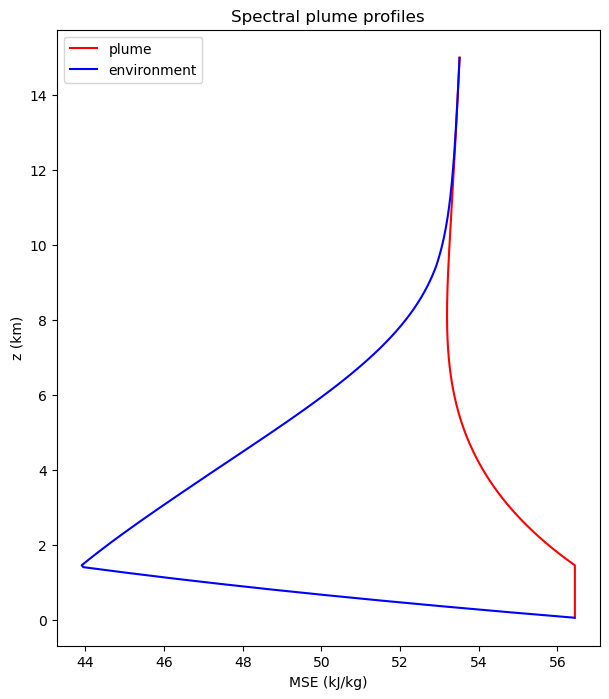

In [11]:
if __name__ == "__main__":
    output = spectral_plume_lcl(model_type="precip",P=3,get_plane = False, plotting=True, save_data=True)
   

In [12]:
from tqdm import tqdm
from multiprocess import Pool

In [13]:
from scipy.interpolate import griddata
def scatter_to_contour(x_in,y_in,z_in):
    # 1D scattered data
    x = np.asarray(x_in)
    y = np.asarray(y_in)
    z = np.asarray(z_in)

    # make regular grid
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # interpolate scattered data onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method="linear")
    return Xi, Yi, Zi

In [71]:
z_lcl = 1400

# 1. Create all (RH, P) pairs
rng = np.random.default_rng(42) ## make things reproducible
RH_values = np.sort(rng.uniform(0.01, 0.99, 100))
P_values = np.sort(rng.uniform(0, 10, 20))
param_pairs = [(RH, P) for RH in RH_values for P in P_values]

# 2. Define worker function
def worker(args):
    RH, P = args
    B, CAPE, dh, sat_def, ent = spectral_plume_lcl(
        model_type="precip", RH=RH, P=P, z_lcl=z_lcl,
        get_plane=True, plotting=False, save_data=False
    )
    return B, CAPE, dh, sat_def, P, ent

# 3. Run in parallel
num_cpus = 5
with Pool(processes=5) as pool:
    results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))

# 4. Unpack results
B_list, CAPE_list, dh_list, sat_def_list, P_list,ent_list = zip(*results)
B_list = list(B_list)
CAPE_list = list(CAPE_list)
dh_list = list(dh_list)
sat_def_list = list(sat_def_list)
P_list = list(P_list)
ent_list = list(ent_list)

100%|██████████| 2000/2000 [02:13<00:00, 14.96it/s]


In [72]:
df = pd.DataFrame({
    "B":B_list,
    "CAPE": CAPE_list,
    "dh": dh_list,
    "sat_def": sat_def_list,
    "P": P_list,
    "ent": ent_list,
            })
df.to_csv(f"LCL_{z_lcl}m.csv", index=False)

In [65]:
import matplotlib.pyplot as plt

In [73]:
sat_def_arr = np.array(sat_def_list)*const.Lv0/1000
dh_arr = np.array(dh_list)/1000
w_arr = np.sqrt(np.array(B_list))

ent_ext = np.percentile(np.asarray(ent_list),10)
mask_ext = np.asarray(ent_list)<ent_ext
w_ext = w_arr[np.asarray(ent_list)<ent_ext]

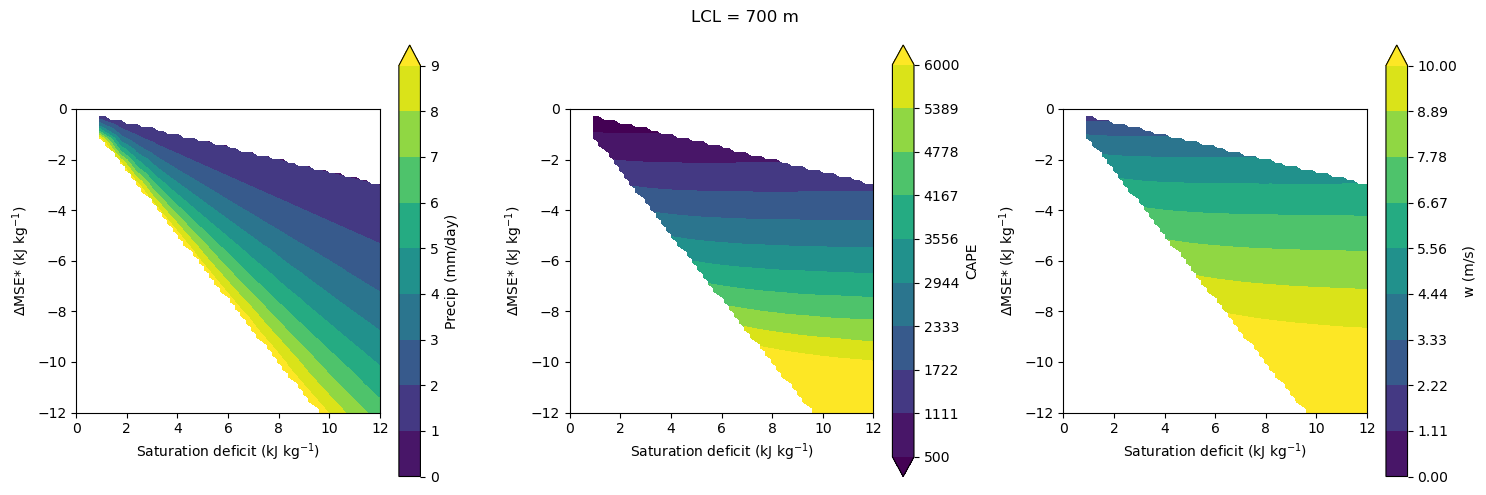

In [70]:
fig = plt.figure(figsize=(15,5))

ax1 = fig.add_subplot(131)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, P_list)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.linspace(0, 9, 10),extend="max")
fig.colorbar(cf1, ax=ax1, label="Precip (mm/day)")
ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.set_aspect('equal')

ax2 = fig.add_subplot(132)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPE_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both")
fig.colorbar(cf2, ax=ax2,label="CAPE")
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(0,10,10),extend="max")
fig.colorbar(cf3, ax=ax3,label="w (m/s)")
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.set_aspect('equal')

plt.suptitle(f"LCL = {z_lcl} m")
plt.tight_layout()

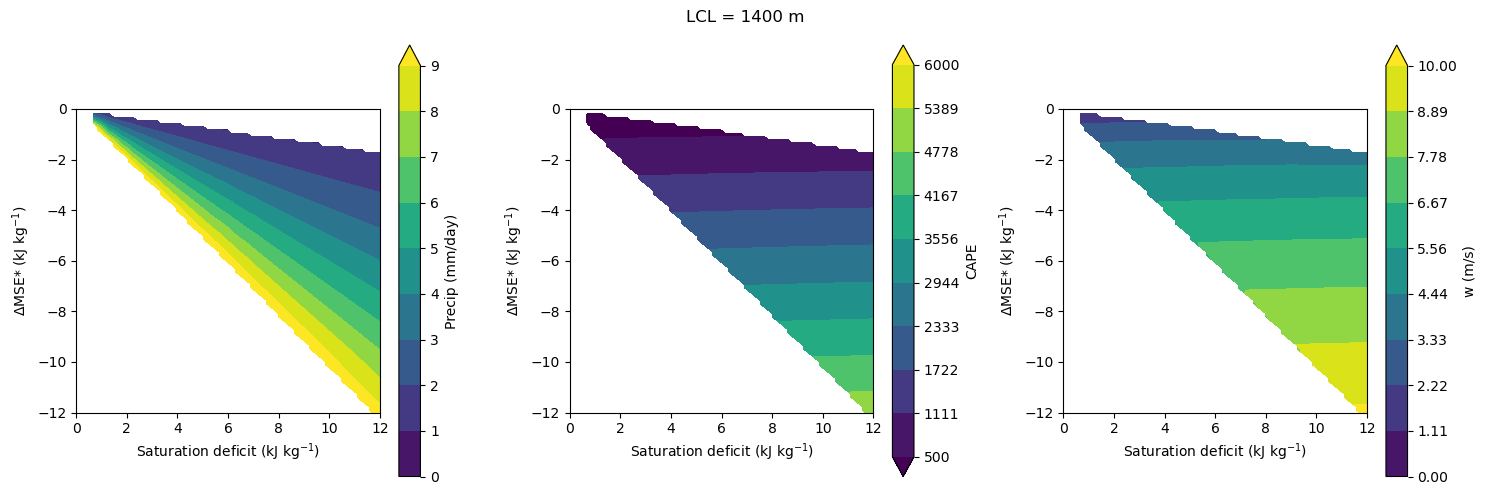

In [78]:
fig = plt.figure(figsize=(15,5))

ax1 = fig.add_subplot(131)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, P_list)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.linspace(0, 9, 10),extend="max")
fig.colorbar(cf1, ax=ax1, label="Precip (mm/day)")
ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.set_aspect('equal')

ax2 = fig.add_subplot(132)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPE_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both")
fig.colorbar(cf2, ax=ax2,label="CAPE")
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(0,10,10),extend="max")
fig.colorbar(cf3, ax=ax3,label="w (m/s)")
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.set_aspect('equal')

plt.suptitle(f"LCL = {z_lcl} m")
plt.tight_layout()

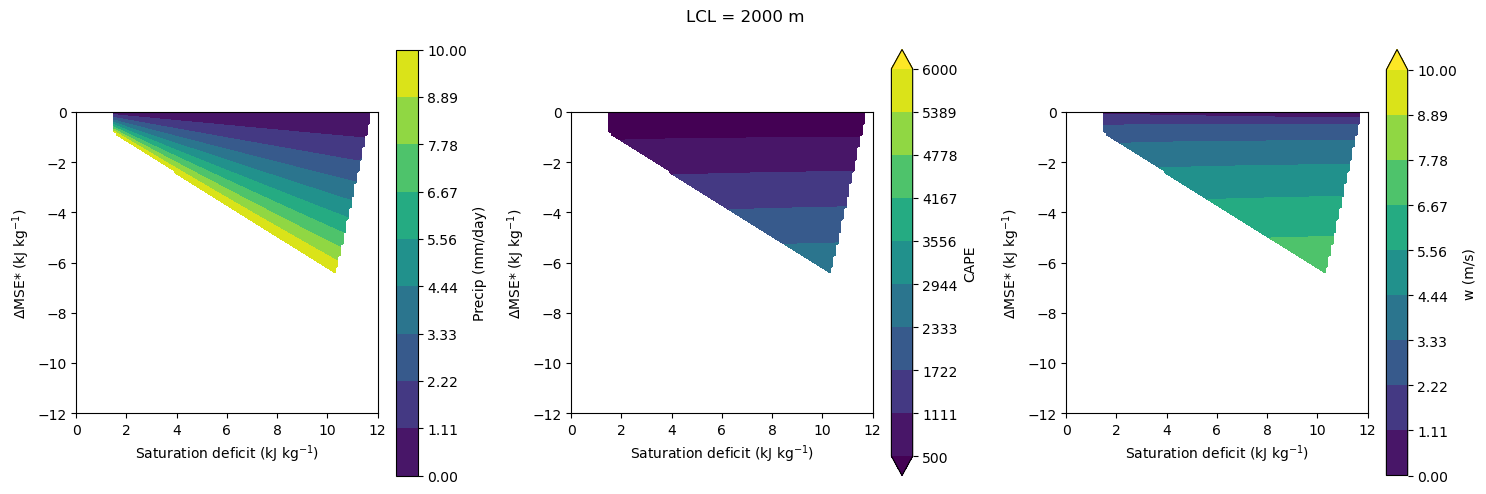

In [225]:
fig = plt.figure(figsize=(15,5))

ax1 = fig.add_subplot(131)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, P_list)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.linspace(0, 10, 10))
fig.colorbar(cf1, ax=ax1, label="Precip (mm/day)")
ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.set_aspect('equal')

ax2 = fig.add_subplot(132)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPE_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both")
fig.colorbar(cf2, ax=ax2,label="CAPE")
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(0,10,10),extend="max")
fig.colorbar(cf3, ax=ax3,label="w (m/s)")
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.set_aspect('equal')

plt.suptitle(f"LCL = {z_lcl} m")
plt.tight_layout()

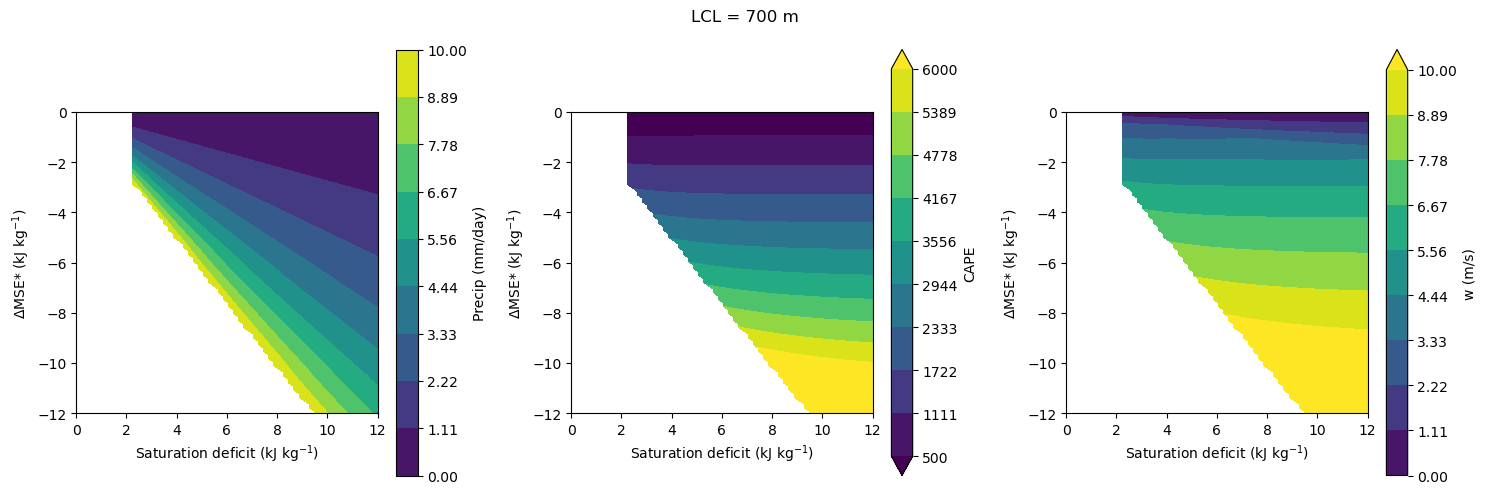

In [220]:
fig = plt.figure(figsize=(15,5))

ax1 = fig.add_subplot(131)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, P_list)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.linspace(0, 10, 10))
fig.colorbar(cf1, ax=ax1, label="Precip (mm/day)")
ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax1.set_aspect('equal')

ax2 = fig.add_subplot(132)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPE_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(500,6000,10),extend="both")
fig.colorbar(cf2, ax=ax2,label="CAPE")
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(0,10,10),extend="max")
fig.colorbar(cf3, ax=ax3,label="w (m/s)")
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta$MSE* (kJ kg$^{-1}$)")
ax3.set_aspect('equal')

plt.suptitle("LCL = 700 m")
plt.tight_layout()